# Phishing URL Detection — Model V2
**Improvements over V1:**
- 30 features (vs 10 in V1)
- Feature scaling with StandardScaler
- Class imbalance handling (class_weight)
- BatchNormalization + Dropout for regularization
- EarlyStopping + ModelCheckpoint callbacks
- Full evaluation: confusion matrix, precision, recall, F1
- Saves in modern .keras format

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import re
import math
import pickle
from pathlib import Path
from urllib.parse import urlparse, parse_qs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print(f"TensorFlow version : {tf.__version__}")
print(f"GPUs available     : {len(tf.config.list_physical_devices('GPU'))}")

TensorFlow version : 2.21.0
GPUs available     : 0


In [2]:
# ── Load Dataset ────────────────────────────────────────────────────────────
data_path = Path("urldata.csv")
df = pd.read_csv(data_path)
df.columns = df.columns.str.strip()

# Keep only URL and label columns
df = df[['url', 'result']].dropna()
df.columns = ['url', 'label']
df['label'] = df['label'].astype(int)

print(f"Total    : {len(df):,}")
print(f"Benign   : {(df['label']==0).sum():,}  ({(df['label']==0).mean()*100:.1f}%)")
print(f"Phishing : {(df['label']==1).sum():,}  ({(df['label']==1).mean()*100:.1f}%)")
df.head()

Total    : 450,180
Benign   : 345,742  (76.8%)
Phishing : 104,438  (23.2%)


,url,label
0,https://www.google.com,0
1,https://www.youtube.com,0
2,https://www.facebook.com,0
3,https://www.baidu.com,0
4,https://www.wikipedia.org,0


In [3]:
# ── Feature Engineering (30 features) ──────────────────────────────────────

# Suspicious TLDs commonly abused by phishers
SUSPICIOUS_TLDS = {
    '.tk', '.ml', '.ga', '.cf', '.gq',
    '.xyz', '.ru', '.pw', '.top', '.club',
    '.online', '.site', '.info', '.biz'
}

# URL shortener domains
SHORTENERS = {
    'bit.ly', 'tinyurl.com', 'goo.gl', 't.co', 'ow.ly',
    'short.link', 'buff.ly', 'adf.ly', 'is.gd', 'cli.gs'
}

# Keywords in path/query that signal phishing
PHISHING_KEYWORDS = [
    'login', 'logon', 'signin', 'sign-in',
    'verify', 'verification', 'validate',
    'secure', 'security', 'account', 'update',
    'confirm', 'password', 'credential',
    'webscr', 'cmd=', 'banking', 'paypal',
    'support', 'auth', 'authenticate'
]

# Well-known brands whose names appear in phishing domains
BRAND_NAMES = [
    'google', 'paypal', 'amazon', 'apple', 'microsoft',
    'facebook', 'instagram', 'netflix', 'twitter', 'linkedin',
    'dropbox', 'yahoo', 'outlook', 'office365', 'chase',
    'wellsfargo', 'bankofamerica', 'ebay', 'alibaba'
]


def shannon_entropy(s: str) -> float:
    """Calculate Shannon entropy of a string."""
    if not s:
        return 0.0
    freq = {c: s.count(c) / len(s) for c in set(s)}
    return -sum(p * math.log2(p) for p in freq.values())


def has_ip_address(url: str) -> int:
    """Return 1 if URL contains an IPv4 address."""
    return int(bool(re.search(
        r'(\d{1,3}\.){3}\d{1,3}', url
    )))


def extract_features(url: str) -> list:
    """
    Extract 30 lexical features from a URL string.
    No external network calls — all computed locally.
    """
    url = str(url).strip()
    url_lower = url.lower()

    # Parse URL components
    try:
        parsed = urlparse(url_lower if url_lower.startswith('http') else 'http://' + url_lower)
        domain = parsed.netloc or url_lower.split('/')[0]
        path   = parsed.path
        query  = parsed.query
    except Exception:
        domain, path, query = url_lower, '', ''

    # Strip www. for cleaner domain analysis
    domain_clean = domain.replace('www.', '')
    subdomains   = domain_clean.split('.')

    # ── URL-level features (1-10) ──────────────────────────────────────────
    f01_url_length        = len(url)
    f02_dot_count         = url.count('.')
    f03_hyphen_count      = url.count('-')
    f04_underscore_count  = url.count('_')
    f05_slash_count       = url.count('/')
    f06_digit_count       = sum(c.isdigit() for c in url)
    f07_special_char_count= len(re.findall(r'[^a-z0-9.\-/:?=&%#@_]', url_lower))
    f08_at_symbol         = int('@' in url)
    f09_double_slash      = int('//' in url[7:])   # ignore scheme //
    f10_url_entropy       = shannon_entropy(url_lower)

    # ── Domain-level features (11-20) ──────────────────────────────────────
    f11_domain_length     = len(domain_clean)
    f12_domain_entropy    = shannon_entropy(domain_clean)
    f13_has_ip            = has_ip_address(url)
    f14_uses_https        = int(url_lower.startswith('https'))
    f15_subdomain_count   = max(0, len(subdomains) - 2)   # parts beyond tld+sld
    f16_domain_has_hyphen = int('-' in domain_clean.split('.')[0] if subdomains else False)
    f17_domain_has_digit  = int(any(c.isdigit() for c in domain_clean))
    f18_suspicious_tld    = int(any(url_lower.endswith(t) or ('.' + t.strip('.') + '/') in url_lower
                                    for t in SUSPICIOUS_TLDS))
    f19_is_shortener      = int(any(s in domain_clean for s in SHORTENERS))
    f20_digit_ratio       = f06_digit_count / max(len(url), 1)

    # ── Brand / keyword features (21-27) ────────────────────────────────────
    # Brand in domain (but domain is NOT the actual brand's registratiojn)
    # e.g. paypal-secure.com  — paypal appears but it's not paypal.com
    tld_sld = '.'.join(subdomains[-2:]) if len(subdomains) >= 2 else domain_clean
    brand_in_subdomain = any(
        brand in domain_clean and brand not in tld_sld
        for brand in BRAND_NAMES
    )
    f21_brand_in_subdomain = int(brand_in_subdomain)

    f22_phish_keyword_url = int(any(kw in url_lower for kw in PHISHING_KEYWORDS))
    f23_phish_keyword_path= int(any(kw in path for kw in PHISHING_KEYWORDS))

    f24_has_port          = int(bool(re.search(r':\d{2,5}/', url)))
    f25_path_length       = len(path)
    f26_query_length      = len(query)
    f27_query_param_count = len(parse_qs(query))

    # ── Structural features (28-30) ─────────────────────────────────────────
    # Number of path segments
    f28_path_depth        = len([p for p in path.split('/') if p])

    # Length of last URL segment (filename-like part)
    last_seg = path.split('/')[-1] if '/' in path else ''
    f29_last_seg_length   = len(last_seg)

    # Digit-to-letter ratio in domain only
    domain_letters = sum(c.isalpha() for c in domain_clean)
    domain_digits  = sum(c.isdigit() for c in domain_clean)
    f30_domain_digit_ratio = domain_digits / max(domain_letters + domain_digits, 1)

    return [
        f01_url_length, f02_dot_count, f03_hyphen_count, f04_underscore_count,
        f05_slash_count, f06_digit_count, f07_special_char_count, f08_at_symbol,
        f09_double_slash, f10_url_entropy,
        f11_domain_length, f12_domain_entropy, f13_has_ip, f14_uses_https,
        f15_subdomain_count, f16_domain_has_hyphen, f17_domain_has_digit,
        f18_suspicious_tld, f19_is_shortener, f20_digit_ratio,
        f21_brand_in_subdomain, f22_phish_keyword_url, f23_phish_keyword_path,
        f24_has_port, f25_path_length, f26_query_length, f27_query_param_count,
        f28_path_depth, f29_last_seg_length, f30_domain_digit_ratio
    ]


FEATURE_NAMES = [
    'url_length', 'dot_count', 'hyphen_count', 'underscore_count',
    'slash_count', 'digit_count', 'special_char_count', 'has_at_symbol',
    'has_double_slash', 'url_entropy',
    'domain_length', 'domain_entropy', 'has_ip_address', 'uses_https',
    'subdomain_count', 'domain_has_hyphen', 'domain_has_digit',
    'suspicious_tld', 'is_url_shortener', 'digit_ratio',
    'brand_in_subdomain', 'phish_keyword_url', 'phish_keyword_path',
    'has_port', 'path_length', 'query_length', 'query_param_count',
    'path_depth', 'last_seg_length', 'domain_digit_ratio'
]

print(f"Total features: {len(FEATURE_NAMES)}")
print("Features:", FEATURE_NAMES)

Total features: 30
Features: ['url_length', 'dot_count', 'hyphen_count', 'underscore_count', 'slash_count', 'digit_count', 'special_char_count', 'has_at_symbol', 'has_double_slash', 'url_entropy', 'domain_length', 'domain_entropy', 'has_ip_address', 'uses_https', 'subdomain_count', 'domain_has_hyphen', 'domain_has_digit', 'suspicious_tld', 'is_url_shortener', 'digit_ratio', 'brand_in_subdomain', 'phish_keyword_url', 'phish_keyword_path', 'has_port', 'path_length', 'query_length', 'query_param_count', 'path_depth', 'last_seg_length', 'domain_digit_ratio']


In [4]:
# ── Extract features from dataset ──────────────────────────────────────────
print("Extracting features... (may take ~2 minutes for 450k rows)")
X_raw = np.array([extract_features(u) for u in df['url']], dtype=np.float32)
y     = df['label'].values.astype(np.float32)
print(f"X shape: {X_raw.shape}  |  y shape: {y.shape}")

Extracting features... (may take ~2 minutes for 450k rows)
X shape: (450180, 30)  |  y shape: (450180,)


In [5]:
# ── Train / Test split ─────────────────────────────────────────────────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y   # stratify = preserve ratio
)
print(f"Train : {X_train_raw.shape}  |  Test : {X_test_raw.shape}")

Train : (360144, 30)  |  Test : (90036, 30)


In [6]:
# ── Feature Scaling ────────────────────────────────────────────────────────
# Fit scaler ONLY on training data — prevent data leakage
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

# Save scaler for inference
with open('scaler_v2.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✅ Scaler fitted and saved to scaler_v2.pkl")

✅ Scaler fitted and saved to scaler_v2.pkl


In [7]:
# ── Handle Class Imbalance ─────────────────────────────────────────────────
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes.astype(int), weights))
print(f"Class weights: {class_weight_dict}")
# This up-weights phishing samples so the model penalises missing them more

Class weights: {np.int64(0): np.float64(0.651033644981453), np.int64(1): np.float64(2.1552603231597844)}


In [8]:
# ── Build Improved Model ───────────────────────────────────────────────────
NUM_FEATURES = X_train.shape[1]

model = Sequential([
    Input(shape=(NUM_FEATURES,)),

    # Block 1
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # Block 2
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # Block 3
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    # Output
    Dense(1, activation='sigmoid')
], name='phishing_detector_v2')

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

model.summary()

Model: "phishing_detector_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,945 (199.00 KB)

 Trainable params: 50,049 (195.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [9]:
# ── Callbacks ──────────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(
        monitor='val_auc',
        mode='max',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'phishing_detector_v2_best.keras',
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# ── Train ──────────────────────────────────────────────────────────────────
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=256,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
1406/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9680 - auc: 0.9891 - loss: 0.0943 - precision: 0.9126 - recall: 0.9667
Epoch 1: val_auc improved from None to 0.99814, saving model to phishing_detector_v2_best.keras

Epoch 1: finished saving model to phishing_detector_v2_best.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9863 - auc: 0.9960 - loss: 0.0544 - precision: 0.9620 - recall: 0.9795 - val_accuracy: 0.9935 - val_auc: 0.9981 - val_loss: 0.0234 - val_precision: 0.9845 - val_recall: 0.9877 - learning_rate: 0.0010
Epoch 2/30
1406/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9927 - auc: 0.9973 - loss: 0.0364 - precision: 0.9828 - recall: 0.9858
Epoch 2: val_auc improved from 0.99814 to 0.99840, saving model to phishing_detector_v2_best.keras

Epoch 2: finished saving model to phishing_detector_v2_best.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9930 - auc: 0.9974 - loss: 0.0356 - precision: 0.9840 - recall: 0.9859 - val_

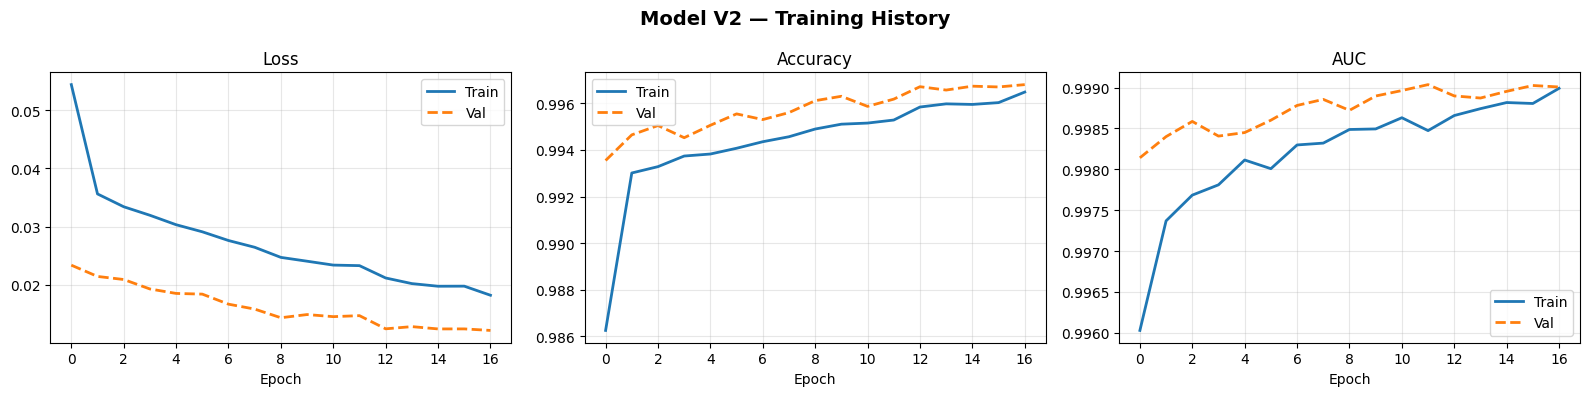

In [10]:
# ── Plot Training History ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, metric, title in zip(
    axes,
    ['loss', 'accuracy', 'auc'],
    ['Loss', 'Accuracy', 'AUC']
):
    ax.plot(history.history[metric],       label='Train', linewidth=2)
    ax.plot(history.history[f'val_{metric}'], label='Val',   linewidth=2, linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Model V2 — Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ── Full Evaluation ────────────────────────────────────────────────────────
y_pred_prob = model.predict(X_test, verbose=0).ravel()
y_pred      = (y_pred_prob >= 0.5).astype(int)

print("=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_test, y_pred,
                             target_names=['Benign', 'Phishing']))

auc_score = roc_auc_score(y_test, y_pred_prob)
print(f"ROC-AUC Score : {auc_score:.4f}")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     69148
    Phishing       0.99      0.99      0.99     20888

    accuracy                           1.00     90036
   macro avg       0.99      0.99      0.99     90036
weighted avg       1.00      1.00      1.00     90036

ROC-AUC Score : 0.9991


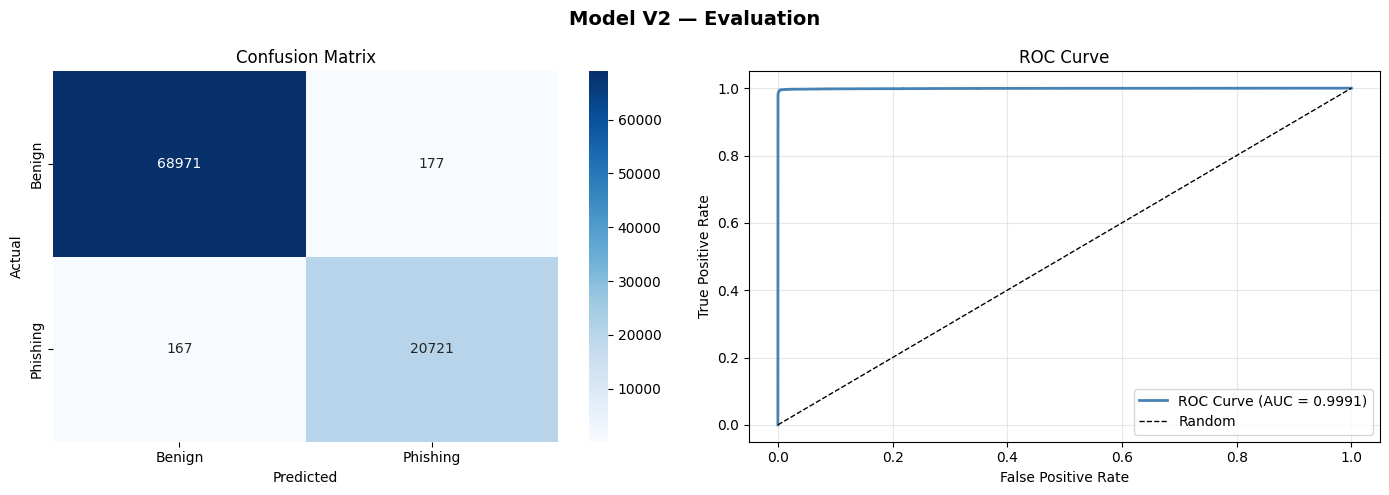


True Negatives  (Benign   → Benign)   : 68,971
False Positives (Benign   → Phishing) : 177  ← false alarms
False Negatives (Phishing → Benign)   : 167  ← missed attacks
True Positives  (Phishing → Phishing) : 20,721


In [12]:
# ── Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Benign', 'Phishing'],
    yticklabels=['Benign', 'Phishing'],
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'ROC Curve (AUC = {auc_score:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Model V2 — Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluation_v2.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (Benign   → Benign)   : {tn:,}")
print(f"False Positives (Benign   → Phishing) : {fp:,}  ← false alarms")
print(f"False Negatives (Phishing → Benign)   : {fn:,}  ← missed attacks")
print(f"True Positives  (Phishing → Phishing) : {tp:,}")

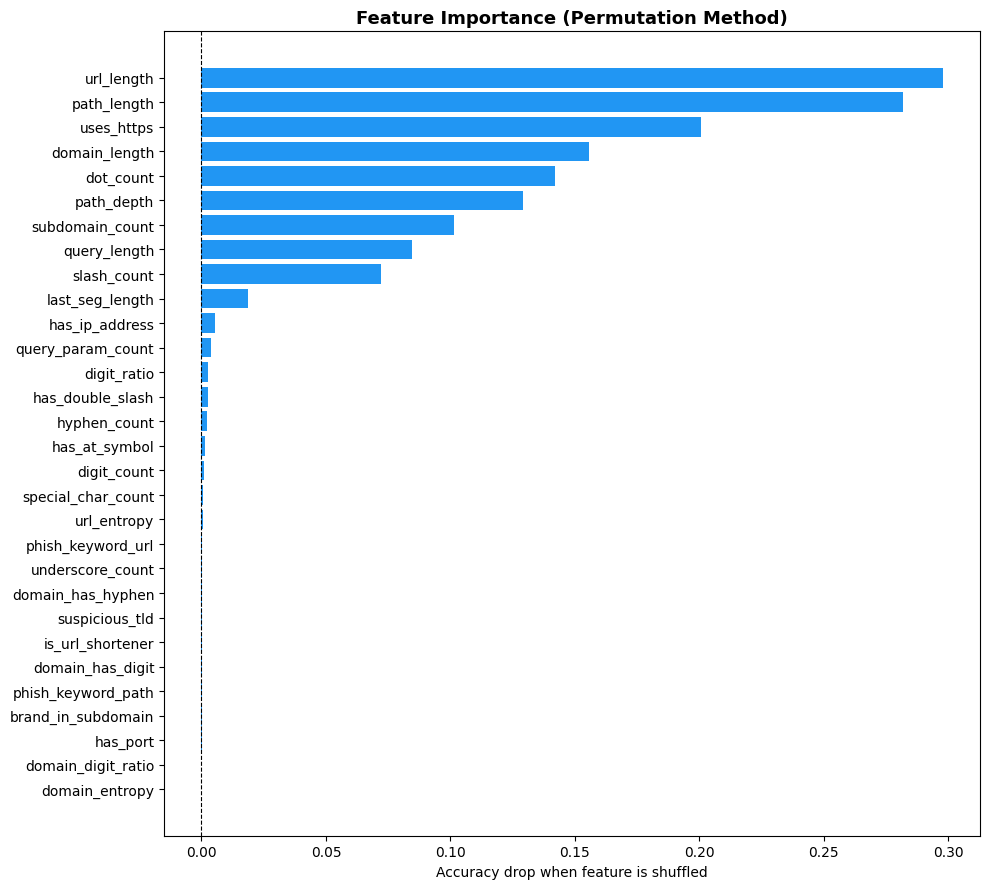

In [13]:
# ── Feature Importance (Permutation-based) ─────────────────────────────────
# Quick approximation: measure accuracy drop when each feature is shuffled
baseline_acc = np.mean((model.predict(X_test, verbose=0).ravel() >= 0.5) == y_test)

importances = []
for i in range(X_test.shape[1]):
    X_perm = X_test.copy()
    np.random.shuffle(X_perm[:, i])
    perm_acc = np.mean((model.predict(X_perm, verbose=0).ravel() >= 0.5) == y_test)
    importances.append(baseline_acc - perm_acc)

fi_df = pd.DataFrame({'feature': FEATURE_NAMES, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=True)

plt.figure(figsize=(10, 9))
colors = ['#2196F3' if v > 0 else '#9E9E9E' for v in fi_df['importance']]
plt.barh(fi_df['feature'], fi_df['importance'], color=colors)
plt.xlabel('Accuracy drop when feature is shuffled')
plt.title('Feature Importance (Permutation Method)', fontsize=13, fontweight='bold')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig('feature_importance_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ── Save Model ─────────────────────────────────────────────────────────────
model.save('phishing_detector_v2.keras')     # modern Keras native format
print("✅ Model saved as phishing_detector_v2.keras")
print("✅ Scaler saved as scaler_v2.pkl")

✅ Model saved as phishing_detector_v2.keras
✅ Scaler saved as scaler_v2.pkl


In [15]:
# ── Inference Function ─────────────────────────────────────────────────────
def predict_url(url: str, model, scaler, threshold: float = 0.5):
    """
    Predict whether a URL is phishing or benign.

    Parameters
    ----------
    url       : URL string to check
    model     : loaded Keras model
    scaler    : fitted StandardScaler
    threshold : decision boundary (default 0.5)

    Returns
    -------
    dict with keys: url, label, confidence, features
    """
    features = np.array([extract_features(url)], dtype=np.float32)
    scaled   = scaler.transform(features)
    prob     = float(model.predict(scaled, verbose=0)[0][0])
    is_phish = prob >= threshold
    return {
        'url'       : url,
        'label'     : '🚨 PHISHING' if is_phish else '✅ BENIGN',
        'confidence': f"{(prob if is_phish else 1 - prob) * 100:.1f}%",
        'raw_score' : round(prob, 4)
    }


# ── Test URLs ──────────────────────────────────────────────────────────────
test_urls = [
    "https://www.google.com",
    "https://www.instagram.com",            # V1 wrongly flagged this
    "http://free-money.tk/click/win",
    "https://www.amazon.com/products/item",
    "http://192.168.1.1/phishing/login.php",
    "http://paypal-secure-login.xyz/verify",
    "https://accounts.google.com.phish.ru/signin",
    "https://github.com/user/repo",
    "http://bit.ly/3xyz123",
    "https://www.netflix.com/browse",
]

print("\n" + "=" * 65)
print("INFERENCE RESULTS")
print("=" * 65)
for url in test_urls:
    result = predict_url(url, model, scaler)
    print(f"{result['label']} ({result['confidence']:>6}) — score={result['raw_score']} — {url}")


INFERENCE RESULTS
✅ BENIGN ( 98.6%) — score=0.0137 — https://www.google.com
✅ BENIGN ( 99.0%) — score=0.0101 — https://www.instagram.com
🚨 PHISHING (100.0%) — score=1.0 — http://free-money.tk/click/win
✅ BENIGN ( 99.6%) — score=0.0045 — https://www.amazon.com/products/item
🚨 PHISHING (100.0%) — score=1.0 — http://192.168.1.1/phishing/login.php
🚨 PHISHING (100.0%) — score=1.0 — http://paypal-secure-login.xyz/verify
🚨 PHISHING (100.0%) — score=0.9996 — https://accounts.google.com.phish.ru/signin
🚨 PHISHING ( 96.3%) — score=0.9632 — https://github.com/user/repo
🚨 PHISHING (100.0%) — score=0.9999 — http://bit.ly/3xyz123
✅ BENIGN ( 99.4%) — score=0.0063 — https://www.netflix.com/browse


## Summary of improvements over V1

| | V1 | V2 |
|---|---|---|
| Features | 10 | 30 |
| Feature scaling | ❌ | ✅ StandardScaler |
| Class imbalance | ❌ | ✅ class_weight |
| Regularization | ❌ | ✅ Dropout + BatchNorm |
| Evaluation | Accuracy only | ✅ Precision, Recall, F1, AUC, Confusion Matrix |
| Callbacks | ❌ | ✅ EarlyStopping, ReduceLR, Checkpoint |
| Stratified split | ❌ | ✅ |
| Model format | `.h5` (deprecated) | `.keras` (native) |
| Entropy features | ❌ | ✅ URL + domain entropy |
| Keyword detection | ❌ | ✅ 20+ phishing keywords |
| Brand spoofing | ❌ | ✅ brand-in-subdomain detection |
| IP address detection | ❌ | ✅ |
| URL shortener detection | ❌ | ✅ |